# NB03 — Sentiment & Earnings Conditioning Overlay
### A risk overlay on the frozen NB02 OU-selected pairs engine — built evidence-first and offline-replayable

**Upstream:** NB02 (frozen statistical engine) · **Downstream:** NB04 (04_conditioned_portfolio — portfolio & ablation)

## What this notebook is — and what it is *not*

NB03 takes the trades NB02 already produced and asks a narrow, honest question for each one:
**given only what was publicly knowable *before* the trade opened, should we hold it as-is, hold it
smaller, or stand aside?** It never generates signals, predicts prices, re-estimates OU parameters,
or alters trade timing. Every NB02 input is loaded read-only.

Two principles keep the overlay honest rather than hindsight. **Point-in-time discipline:** a trade's
evidence is drawn only from information publicly available on or before its entry date — never from
anything that surfaced afterward. **Coverage realism:** where there isn't enough news to form a
reliable view, the overlay abstains and records that it did, rather than manufacturing a signal. From
these falls the study's real subject — in Latin-American ADRs, **the binding constraint on a sentiment
overlay is coverage itself**: for much of the universe there simply isn't enough news to act on. This
notebook measures *where* a sentiment signal can exist at all, applies a bounded policy only there,
and hands the result to NB04 for performance evaluation. It is a **replication-boundary study**, not a
performance pitch.

**The flow below:** ① the frozen inputs and how a spread direction becomes per-leg long/short →
② as-of evidence and the coverage cliff, plus why the *sign* of sentiment is unusable here →
③ a worked example → ④ the two-gate policy and what it actually touched → ⑤ the conditioned
artifacts handed to NB04.

## 1. Layer A — Frozen inputs & the leg map

We inherit three artifacts from NB02 and treat them as immutable. The only column gymnastics NB03 does
is recovering, for each trade, **which underlying is long and which is short** — because the legs
live only in `pairs_metadata`, while `trades_table` carries just the pair string and a direction.

### 1.0 Environment & fixed parameters

All tunable parameters are fixed here, up front, so the policy is auditable at a glance. `.env` is loaded with `override=True` so it always beats a stale exported key, and `OFFLINE_MODE=1` replays the whole notebook from cached artifacts with no network.

In [1]:
# ==============================================================================
# Environment & locked-contract parameters
# ==============================================================================
from __future__ import annotations
import os, sys, json, hashlib, datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# .env wins over any stale exported var (the load_dotenv override=False footgun)
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True), override=True)
except ImportError:
    pass

# Repo bootstrap so `from src.config` / `from src.io` resolves
def _add_repo_root_to_syspath():
    cur = Path.cwd().resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "requirements.txt").exists() or (parent / ".git").exists():
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            return
_add_repo_root_to_syspath()

from src.config import PATHS, OFFLINE_MODE, EODHD_API_KEY, ROOT
from src.io import EODHDClient

def find_project_root(start: Path | None = None) -> Path:
    """Walk up until we find the repo (works whether NB runs at root or in notebooks/)."""
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "artifacts" / "nb2_outputs").exists() or (p / ".git").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()
NB2_DIR      = PROJECT_ROOT / "artifacts" / "nb2_outputs"
NB3_DIR      = PROJECT_ROOT / "artifacts" / "nb3_outputs"
NEWS_CACHE   = NB3_DIR / "_api_cache"
NB3_DIR.mkdir(parents=True, exist_ok=True)
NEWS_CACHE.mkdir(parents=True, exist_ok=True)
assert NB2_DIR.exists(), f"NB2 artifacts not found under {NB2_DIR}"

# ---- LOCKED contract parameters --------------------------------------------------------
L_DAYS                 = 7            # as-of sentiment lookback (calendar days)
COVERAGE_L_GRID        = [7, 14, 21]  # coverage audit reported at these L (robustness)
MIN_COVERAGE_COUNT     = 3            # articles in as-of window to trust the gate
BASELINE_DAYS          = 180          # trailing window for per-name tone percentiles
MIN_BASELINE_COUNT     = 20           # min articles to form a stable p10/p90 baseline
TONE_LOW_PCTL          = 10           # long-leg blocked if window tone <= name's p10
TONE_HIGH_PCTL         = 90           # short-leg blocked if window tone >= name's p90
EARNINGS_LOOKAHEAD_DAYS = 33           # = median holding period (n_days); see A.1 diagnostic. NB4 sweeps K.
DOWNSIZE_MULT          = 0.5          # exact linear resize
POLICY                 = "earnings=BLOCK, sentiment=DOWNSIZE"

# ---- EODHD config --------------------------------------------------------
TICKER_SUFFIX = ".US"   # ADR universe is US-listed
print(f"[INFO] repo={ROOT.name}  OFFLINE_MODE={OFFLINE_MODE}")

[INFO] repo=ai-pairs-trading  OFFLINE_MODE=True


### 1.1 Load the NB02 artifacts by name

We assert the exact schema rather than guess columns — if NB02's output ever drifts (a renamed column, a transposed time series), this cell fails immediately and loudly instead of silently mis-reading. The `direction` print is a one-time check that the encoding is what we expect.

In [2]:
# ==============================================================================
# A.1 — Load NB2 artifacts BY NAME (frozen; no recomputation) + lock the schema
# ==============================================================================
PAIRS_META = pd.read_csv(NB2_DIR / "pairs_metadata.csv")
TRADES     = pd.read_csv(NB2_DIR / "trades_table.csv")
PAIR_TS    = pd.read_parquet(NB2_DIR / "pair_timeseries.parquet")

META_COLS  = ["pair", "Ticker1", "Ticker2", "rho", "alpha", "beta",
              "phi", "halflife", "r2", "eg_p", "adf_p", "Nobs"]
TRADE_COLS = ["pair", "entry_date", "exit_date", "direction",
              "entry_pos", "entry_z", "exit_z", "n_days", "trade_pnl"]
TS_COLS    = ["date", "pair", "spread", "zscore", "position", "pnl"]
for df, cols, name in [(PAIRS_META, META_COLS, "pairs_metadata"),
                       (TRADES, TRADE_COLS, "trades_table"),
                       (PAIR_TS, TS_COLS, "pair_timeseries")]:
    missing = [c for c in cols if c not in df.columns]
    assert not missing, f"{name} missing columns {missing}; got {list(df.columns)}"

TRADES["entry_date"] = pd.to_datetime(TRADES["entry_date"])
TRADES["exit_date"]  = pd.to_datetime(TRADES["exit_date"])
PAIR_TS["date"]      = pd.to_datetime(PAIR_TS["date"])
assert (TRADES["entry_date"] <= TRADES["exit_date"]).all(), "entry after exit"

TRADES = TRADES.reset_index(drop=True)
TRADES["trade_id"] = TRADES.index   # stable id for the evidence join

print(f"pairs={len(PAIRS_META)}  trades={len(TRADES)}  ts_rows={len(PAIR_TS)}")
print("direction unique values (VERIFY encoding):", sorted(TRADES['direction'].unique().tolist()))
print("holding period n_days (median / p75 / max):",
      int(TRADES['n_days'].median()), int(TRADES['n_days'].quantile(0.75)), int(TRADES['n_days'].max()),
      "  <- EARNINGS_LOOKAHEAD_DAYS (K) should track the typical hold")

pairs=20  trades=283  ts_rows=17220
direction unique values (VERIFY encoding): ['LONG', 'SHORT']
holding period n_days (median / p75 / max): 33 55 171   <- EARNINGS_LOOKAHEAD_DAYS (K) should track the typical hold


### 1.2 From spread direction to leg sides

A pairs position is one spread, not two free trades. By convention a **long-spread** position
(`direction > 0`) is **long `Ticker1` and short `β·Ticker2`**; a short-spread is the mirror. So the
sentiment gate, which is inherently one-sided ("bad news for a long leg", "good news for a short
leg"), needs this map to know which side each leg is on. We build it once, per trade × leg.

In [3]:
# ==============================================================================
# A.2 — Leg-sign contract: long-spread = LONG Ticker1 / SHORT beta*Ticker2
# ==============================================================================
def norm_direction(d) -> int:
    """Normalize NB2 'direction' to +1 (long spread) / -1 (short spread)."""
    if isinstance(d, str):
        u = d.strip().upper()
        if u in ("LONG", "L", "+1", "1"):  return 1
        if u in ("SHORT", "S", "-1"):      return -1
        raise ValueError(f"unrecognized direction {d!r}")
    return 1 if float(d) >= 0 else -1

TRADES["dir_norm"] = TRADES["direction"].map(norm_direction)
assert set(TRADES["dir_norm"].unique()) <= {-1, 1}

meta_legs = PAIRS_META.set_index("pair")[["Ticker1", "Ticker2", "beta"]]
leg_rows = []
for r in TRADES.itertuples(index=False):
    assert r.pair in meta_legs.index, f"pair {r.pair} absent from pairs_metadata"
    t1, t2, beta = meta_legs.loc[r.pair, ["Ticker1", "Ticker2", "beta"]]
    side1 = "LONG"  if r.dir_norm > 0 else "SHORT"   # Ticker1 follows the spread sign
    side2 = "SHORT" if r.dir_norm > 0 else "LONG"    # Ticker2 (the beta leg) is opposite
    leg_rows.append(dict(trade_id=r.trade_id, pair=r.pair, leg=1, ticker=str(t1),
                         leg_side=side1, beta=float(beta),
                         entry_date=r.entry_date, exit_date=r.exit_date))
    leg_rows.append(dict(trade_id=r.trade_id, pair=r.pair, leg=2, ticker=str(t2),
                         leg_side=side2, beta=float(beta),
                         entry_date=r.entry_date, exit_date=r.exit_date))
LEGS = pd.DataFrame(leg_rows)
UNIQUE_TICKERS = sorted(LEGS["ticker"].unique().tolist())
print(f"trade-legs={len(LEGS)}  unique leg tickers={len(UNIQUE_TICKERS)}")
print("tickers:", UNIQUE_TICKERS)

trade-legs=566  unique leg tickers=20
tickers: ['ASR', 'BAP', 'BBAR', 'CAAP', 'CEPU', 'CX', 'DLO', 'ERJ', 'GLOB', 'IFS', 'MELI', 'NU', 'PAGS', 'PAX', 'SUPV', 'VINP', 'VIST', 'VLRS', 'VTEX', 'XP']


### 1.3 Sanity check — the derived legs

A quick look that the direction → side mapping is concrete and correct before we build anything on top of it.

In [4]:
preview = (LEGS.merge(TRADES[["trade_id", "dir_norm", "entry_z"]], on="trade_id")
               .loc[:, ["trade_id", "pair", "dir_norm", "leg", "ticker", "leg_side", "entry_date"]]
               .head(8))
preview

,trade_id,pair,dir_norm,leg,ticker,leg_side,entry_date
0,0,NU-VTEX,-1,1,NU,SHORT,2023-04-21
1,0,NU-VTEX,-1,2,VTEX,LONG,2023-04-21
2,1,NU-VTEX,1,1,NU,LONG,2023-08-17
3,1,NU-VTEX,1,2,VTEX,SHORT,2023-08-17
4,2,NU-VTEX,1,1,NU,LONG,2024-01-31
5,2,NU-VTEX,1,2,VTEX,SHORT,2024-01-31
6,3,NU-VTEX,-1,1,NU,SHORT,2024-02-07
7,3,NU-VTEX,-1,2,VTEX,LONG,2024-02-07


## 2. Layer B — As-of evidence & the coverage boundary

This is the heart of the rebuild. For every trade leg we reconstruct what the news looked like in the
window **ending on (and never after) the entry date**, using EODHD `/api/news`. We chose `/api/news`
over the aggregated `/api/sentiments` endpoint deliberately: it is the same article corpus but exposes
**signed per-article tone** and **article timestamps**, so the as-of cut `published ≤ entry` is exact.

We fetch each ticker's news **once** over the whole span and persist it, then build every piece of
evidence offline from that file — so the study is reproducible without ever hitting the API again.

### 2.0 A cached, redacted news/earnings client

Thin wrapper over EODHD with an on-disk cache. The API token is read from the environment and **never** printed; any HTTP error is redacted at the source.

In [5]:
# === EODHD client (shared with NB01 / NB02 via src.io) ===
client = EODHDClient()
print(f"[INFO] EODHD client ready  |  OFFLINE_MODE={OFFLINE_MODE}  |  "
      f"cache={client.cache_dir.relative_to(ROOT)}")

[INFO] EODHD client ready  |  OFFLINE_MODE=True  |  cache=data/cache


### 2.1 Fetch once, persist, replay

Pull news + the earnings calendar across `[earliest entry − baseline, latest exit]` and write `news_long.parquet` / `earnings_raw.parquet`. After this runs once online, everything downstream is offline-replayable.

In [6]:
# ==============================================================================
# B.1 — Fetch news + earnings over the span and PERSIST (fetch-once / replay)
# ==============================================================================
span_lo = (TRADES["entry_date"].min()
           - pd.Timedelta(days=BASELINE_DAYS + L_DAYS + 5)).date().isoformat()
span_hi = TRADES["exit_date"].max().date().isoformat()
print(f"news/earnings span: {span_lo} -> {span_hi}")

news_frames = []
for tk in UNIQUE_TICKERS:
    code = f"{tk}{TICKER_SUFFIX}"
    arts = client.news(code, from_date=span_lo, to_date=span_hi)
    rows = []
    for a in arts:
        s = a.get("sentiment") or {}
        d = a.get("date")
        if not d or "pos" not in s or "neg" not in s:
            continue
        rows.append({"ticker": tk,
                     "date": pd.to_datetime(d, utc=True),
                     "pos": float(s["pos"]), "neg": float(s["neg"]),
                     "polarity": s.get("polarity")})
    print(f"  {code}: {len(rows)} usable articles")
    if rows:
        news_frames.append(pd.DataFrame(rows))

NEWS_COLS = ["ticker", "date", "pos", "neg", "polarity"]
news_long = (pd.concat(news_frames, ignore_index=True)
             if news_frames else pd.DataFrame(columns=NEWS_COLS))
news_long.to_parquet(NB3_DIR / "news_long.parquet", index=False)

earn_codes   = [f"{tk}{TICKER_SUFFIX}" for tk in UNIQUE_TICKERS]
earn_payload = client.earnings_calendar(from_date=span_lo, to_date=span_hi, symbols=",".join(earn_codes))
earn_recs    = earn_payload.get("earnings", []) if isinstance(earn_payload, dict) else (earn_payload or [])
EARN = pd.DataFrame(earn_recs)
if not EARN.empty:
    EARN["report_date"] = pd.to_datetime(EARN["report_date"])
    EARN["ticker"]      = EARN["code"].str.replace(r"\.US$", "", regex=True)
EARN.to_parquet(NB3_DIR / "earnings_raw.parquet", index=False)
print(f"news rows persisted: {len(news_long)}   earnings records: {len(EARN)}")

news/earnings span: 2022-09-12 -> 2026-05-29
  ASR.US: 203 usable articles
  BAP.US: 375 usable articles
  BBAR.US: 109 usable articles
  CAAP.US: 230 usable articles
  CEPU.US: 68 usable articles
  CX.US: 282 usable articles
  DLO.US: 543 usable articles
  ERJ.US: 718 usable articles
  GLOB.US: 513 usable articles
  IFS.US: 194 usable articles
  MELI.US: 3194 usable articles
  NU.US: 1335 usable articles
  PAGS.US: 507 usable articles
  PAX.US: 302 usable articles
  SUPV.US: 81 usable articles
  VINP.US: 68 usable articles
  VIST.US: 264 usable articles
  VLRS.US: 153 usable articles
  VTEX.US: 190 usable articles
  XP.US: 378 usable articles
news rows persisted: 9707   earnings records: 299


### 2.2 Build the evidence — and the coverage audit

For each trade leg we compute, strictly as-of entry: the article **count** in the window, the
count-weighted **net tone** `pos − neg`, and the name's own trailing **p10 / p90** tone percentiles.
A leg is **COVERED** only if it clears both a window-count floor (so one article can't swing the
signal) and a baseline floor (so the percentiles are stable); otherwise it is logged explicitly as
**`NO_EVIDENCE`**. That `semantic_evidence.parquet` file *is* the coverage audit.

In [7]:
# ==============================================================================
# B.2 — Build semantic_evidence.parquet (per trade x leg, as-of). = coverage audit.
# ==============================================================================
news_long = pd.read_parquet(NB3_DIR / "news_long.parquet")
EARN      = pd.read_parquet(NB3_DIR / "earnings_raw.parquet")
if len(news_long):
    news_long["day"] = news_long["date"].dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize()
    news_long["net"] = news_long["pos"].astype(float) - news_long["neg"].astype(float)

def _name_news(tk: str) -> pd.DataFrame:
    return news_long[news_long["ticker"] == tk] if len(news_long) else news_long

def asof_window(tk: str, entry, L: int) -> pd.DataFrame:
    nn = _name_news(tk)
    if not len(nn):
        return nn
    hi = pd.Timestamp(entry).normalize()
    lo = hi - pd.Timedelta(days=L)
    return nn[(nn["day"] > lo) & (nn["day"] <= hi)]      # strict as-of: day <= entry_date

def baseline_pctls(tk: str, entry):
    nn = _name_news(tk)
    if not len(nn):
        return (np.nan, np.nan, 0)
    hi = pd.Timestamp(entry).normalize()
    lo = hi - pd.Timedelta(days=BASELINE_DAYS)
    b  = nn[(nn["day"] > lo) & (nn["day"] <= hi)]
    if len(b) < MIN_BASELINE_COUNT:
        return (np.nan, np.nan, len(b))
    # percentiles over DAILY-MEAN net tone so the reference matches the window signal's
    # granularity (the as-of signal is a multi-day mean, not a single article).
    daily = b.groupby("day")["net"].mean()
    return (float(np.percentile(daily, TONE_LOW_PCTL)),
            float(np.percentile(daily, TONE_HIGH_PCTL)), len(b))

def earnings_near(tk: str, entry):
    """Point-in-time earnings risk: would we be OPENING into an imminent scheduled report?
    Uses only information known at entry — the scheduled calendar — never the realized exit.
    Fires if a leg reports within [entry, entry + EARNINGS_LOOKAHEAD_DAYS]."""
    if EARN.empty:
        return (False, pd.NaT, None)
    e = EARN[EARN["ticker"] == tk]
    if not len(e):
        return (False, pd.NaT, None)
    lo  = pd.Timestamp(entry).normalize()
    hi  = lo + pd.Timedelta(days=EARNINGS_LOOKAHEAD_DAYS)
    hit = e[(e["report_date"] >= lo) & (e["report_date"] <= hi)]
    if not len(hit):
        return (False, pd.NaT, None)
    row = hit.sort_values("report_date").iloc[0]
    baf = row.get("before_after_market")
    return (True, row["report_date"], (None if pd.isna(baf) else baf))

ev = []
for r in LEGS.itertuples(index=False):
    w   = asof_window(r.ticker, r.entry_date, L_DAYS)
    cnt = len(w)
    tone = float(w["net"].mean()) if cnt else np.nan
    p_lo, p_hi, bcnt = baseline_pctls(r.ticker, r.entry_date)
    covered = (cnt >= MIN_COVERAGE_COUNT) and (bcnt >= MIN_BASELINE_COUNT)
    if not covered:
        gate = "NO_EVIDENCE"                                   # logged, never silent
    elif (p_hi - p_lo) < 1e-9:
        gate = "CLEAR"                                         # baseline has no spread -> no signal
    elif r.leg_side == "LONG":
        gate = "VIOLATION" if tone <= p_lo else "CLEAR"        # adverse = abnormally negative
    else:  # SHORT
        gate = "VIOLATION" if tone >= p_hi else "CLEAR"        # adverse = abnormally positive
    e_hit, e_date, e_baf = earnings_near(r.ticker, r.entry_date)
    ev.append(dict(
        trade_id=r.trade_id, pair=r.pair, leg=r.leg, ticker=r.ticker, leg_side=r.leg_side,
        entry_date=r.entry_date, exit_date=r.exit_date,
        asof_lo=pd.Timestamp(r.entry_date).normalize() - pd.Timedelta(days=L_DAYS),
        asof_hi=pd.Timestamp(r.entry_date).normalize(),
        sent_count=cnt, sent_net_tone=tone, base_count=bcnt,
        tone_p10=p_lo, tone_p90=p_hi,
        evidence_status=("COVERED" if covered else "NO_EVIDENCE"),
        dir_gate=gate,
        earnings_in_window=e_hit, earnings_report_date=e_date, earnings_baf=e_baf,
    ))
EVID = pd.DataFrame(ev)
EVID.to_parquet(NB3_DIR / "semantic_evidence.parquet", index=False)
print("evidence rows:", len(EVID))
print(EVID["evidence_status"].value_counts().to_string())
print(EVID["dir_gate"].value_counts().to_string())

evidence rows: 566
evidence_status
NO_EVIDENCE    319
COVERED        247
dir_gate
NO_EVIDENCE    319
CLEAR          236
VIOLATION       11


In [8]:
# ==============================================================================
# B.3 — Coverage audit (the replication boundary), reported at L in {7,14,21}
# ==============================================================================
def coverage_at(L: int) -> float:
    flags = []
    for r in LEGS.itertuples(index=False):
        cnt = len(asof_window(r.ticker, r.entry_date, L))
        _, _, bcnt = baseline_pctls(r.ticker, r.entry_date)
        flags.append((cnt >= MIN_COVERAGE_COUNT) and (bcnt >= MIN_BASELINE_COUNT))
    return float(np.mean(flags)) if flags else 0.0

cov_summary = {L: round(100 * coverage_at(L), 1) for L in COVERAGE_L_GRID}
print("Trade-leg coverage % by L:", cov_summary)

per_tk = (EVID.assign(cov=EVID["evidence_status"].eq("COVERED"))
              .groupby("ticker")["cov"].mean().mul(100).round(1).sort_values())
print(f"\nPer-ticker coverage % (L={L_DAYS}):")
print(per_tk.to_string())

Trade-leg coverage % by L: {7: 43.6, 14: 59.7, 21: 69.8}

Per-ticker coverage % (L=7):
ticker
VINP     0.0
CEPU     0.0
SUPV     6.2
IFS      7.1
CX       7.7
BBAR    12.5
VLRS    16.7
ASR     16.7
CAAP    22.2
VIST    25.0
VTEX    25.9
BAP     28.6
PAX     30.8
XP      41.4
PAGS    45.2
GLOB    50.0
DLO     54.1
NU      71.6
ERJ     80.0
MELI    89.1


### 2.3 The coverage cliff

News volume spans orders of magnitude across this universe: a mega-cap ADR like MercadoLibre carries
hundreds of articles over a six-month window, while a thinner name carries a handful. The chart below
turns that into the number that actually governs the overlay — **what fraction of trade legs can the
sentiment gate even see** — across three lookback lengths. This is the replication boundary, made
concrete.

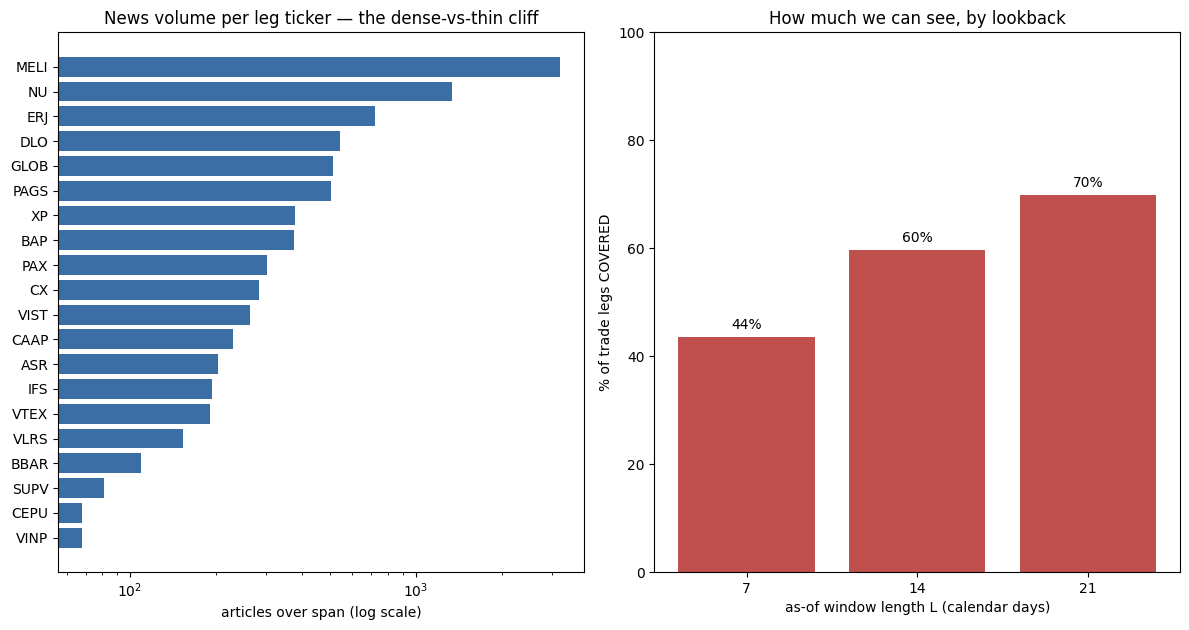

In [9]:
# ---- Chart 1: the coverage cliff ----------------------------------------------------------
vol = (news_long.groupby("ticker").size().sort_values(ascending=True)
       if len(news_long) else pd.Series(dtype=int))
fig, ax = plt.subplots(1, 2, figsize=(12, max(3.5, 0.32 * max(len(vol), 1))))
if len(vol):
    ax[0].barh(vol.index, vol.values.clip(min=0.5), color="#3b6ea5")
    ax[0].set_xscale("log")
    ax[0].set_xlabel("articles over span (log scale)")
    ax[0].set_title("News volume per leg ticker — the dense-vs-thin cliff")
else:
    ax[0].text(0.5, 0.5, "no news returned", ha="center", va="center")
ax[1].bar([str(L) for L in COVERAGE_L_GRID],
          [cov_summary[L] for L in COVERAGE_L_GRID], color="#c0504d")
ax[1].set_ylim(0, 100)
ax[1].set_ylabel("% of trade legs COVERED")
ax[1].set_xlabel("as-of window length L (calendar days)")
ax[1].set_title("How much we can see, by lookback")
for i, L in enumerate(COVERAGE_L_GRID):
    ax[1].text(i, cov_summary[L] + 1.5, f"{cov_summary[L]:.0f}%", ha="center")
plt.tight_layout(); plt.show()

What to read here: lengthening the window barely lifts coverage, because thin names don't have
*sparse* news — they have *almost no* news. They stay below the floor at every reasonable `L`, and
beyond ~3 weeks the news is too stale to condition a mean-reversion entry anyway. So thin names
abstain honestly. The sentiment overlay is, by construction, only ever active on the dense
sub-universe — and quantifying that is half the result.

### 2.4 Why the *sign* of sentiment is unusable here

The natural design — "block a long leg on negative sentiment" — assumes sentiment has a usable sign.
It doesn't, here. EODHD's per-article **polarity** is a VADER-style compound score (Hutto & Gilbert, 2014) that saturates
hard against +1 (median ≈ +0.997; only single-digit-% of articles are negative). Gating on its sign
would veto almost every *short* leg and almost no *long* leg — an accidental short-veto, not a
sentiment gate. The finer **`pos − neg`** breakdown, by contrast, has real spread. That is why the
gate uses net tone judged **relative to each name's own history** (p10 / p90), not an absolute sign.

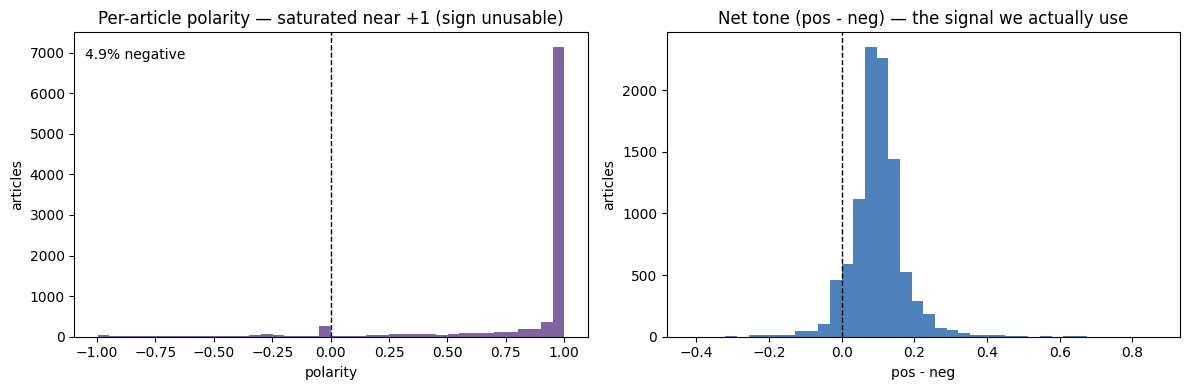

In [10]:
# ---- Chart 2: polarity is saturated (left) -> we use net tone, judged per-name (right) ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
if len(news_long):
    pol = news_long["polarity"].dropna().astype(float)
    net = (news_long["pos"].astype(float) - news_long["neg"].astype(float)).dropna()
    if len(pol):
        ax[0].hist(pol, bins=40, color="#8064a2")
        ax[0].text(0.02, 0.95, f"{100*(pol < 0).mean():.1f}% negative",
                   transform=ax[0].transAxes, va="top")
    ax[0].axvline(0, color="k", ls="--", lw=1)
    ax[0].set_title("Per-article polarity — saturated near +1 (sign unusable)")
    ax[0].set_xlabel("polarity"); ax[0].set_ylabel("articles")
    ax[1].hist(net, bins=40, color="#4f81bd")
    ax[1].axvline(0, color="k", ls="--", lw=1)
    ax[1].set_title("Net tone (pos - neg) — the signal we actually use")
    ax[1].set_xlabel("pos - neg"); ax[1].set_ylabel("articles")
else:
    for a in ax: a.text(0.5, 0.5, "no news returned", ha="center", va="center")
plt.tight_layout(); plt.show()

### 2.5 A trade, end to end

To make the machinery concrete, here is one COVERED trade traced through the whole evidence layer:
its two legs, the as-of window, each leg's net tone against that name's own p10/p90 band, and the
gate call that falls out. (If no trade is COVERED in a given run, that message *is* the finding.)

In [11]:
# ---- Worked example: one covered trade, leg by leg ----------------------------------------
cov_legs = EVID[EVID["evidence_status"] == "COVERED"]
if len(cov_legs):
    tid  = int(cov_legs["trade_id"].iloc[0])
    legs = EVID[EVID["trade_id"] == tid]
    tr   = TRADES[TRADES["trade_id"] == tid].iloc[0]
    print(f"Trade {tid}: {tr['pair']}  "
          f"{tr['entry_date'].date()} -> {tr['exit_date'].date()}  dir={tr['dir_norm']:+d}")
    print(f"  as-of window: {legs['asof_lo'].iloc[0].date()} .. "
          f"{legs['asof_hi'].iloc[0].date()}  (L={L_DAYS}d)")
    for r in legs.itertuples(index=False):
        line = (f"  leg{r.leg} {r.ticker:<6} {r.leg_side:<5} | "
                f"count={r.sent_count:>3}  tone={r.sent_net_tone:+.3f}  "
                f"[p10={r.tone_p10:+.3f}, p90={r.tone_p90:+.3f}]  -> {r.dir_gate}")
        if r.earnings_in_window:
            line += f"  | earnings {pd.Timestamp(r.earnings_report_date).date()}"
        print(line)
else:
    print("No COVERED legs this run — every trade fell to NO_EVIDENCE.")
    print("That is itself the headline: for this book, sentiment is largely unobservable as-of entry.")

Trade 1: NU-VTEX  2023-08-17 -> 2023-09-13  dir=+1
  as-of window: 2023-08-10 .. 2023-08-17  (L=7d)
  leg1 NU     LONG  | count=  3  tone=+0.042  [p10=-0.032, p90=+0.194]  -> CLEAR
  leg2 VTEX   SHORT | count=  0  tone=+nan  [p10=+nan, p90=+nan]  -> NO_EVIDENCE


## 3. Layer C — Bounded policy (two separate gates)

Two gates, kept deliberately separate, with the response matched to the reliability of the signal:

| Gate | Scope | Condition | Action |
|---|---|---|---|
| **Earnings** | every trade | a leg reports within `K` days **after entry** (`report_date ∈ [entry, entry+K]`) | **BLOCK** (drop) |
| **Sentiment** | COVERED legs only | LONG leg tone ≤ name p10, or SHORT leg tone ≥ name p90 | **DOWNSIZE** (0.5×) |
| — | `NO_EVIDENCE` / `CLEAR` | — | **ALLOW** (logged) |

Earnings is a scheduled, discrete jump that breaks the OU mean-reversion premise outright — a hard
veto. Crucially, the gate is **point-in-time**: it asks only whether a trade would be opened into — and
then *held through* — an already-scheduled report, using the earnings calendar as known at entry. It
never consults the realized exit date, so the decision is one that could have been made live — no
hindsight enters. `K` is set to the **median holding period** (≈33 days in this run): because a typical
trade spans that horizon, the gate captures the realistic case of being *held through* a report rather
than merely opened just before one. `K` is chosen on this ex-ante principle, not tuned to outcomes;
NB04 reports how the result moves across a grid of `K`.
Adverse sentiment, by contrast, is a soft, noisy lean — a resize, not a veto. `BLOCK` dominates
`DOWNSIZE` when both fire. Shock attribution (next) is analytics only and never touches sizing.

In [12]:
# ==============================================================================
# C.1 — Apply the two gates and reduce to one action per trade (BLOCK > DOWNSIZE > ALLOW)
# ==============================================================================
EVID = pd.read_parquet(NB3_DIR / "semantic_evidence.parquet")

def reduce_trade(g: pd.DataFrame) -> pd.Series:
    earnings_block = bool(g["earnings_in_window"].any())            # universal
    sentiment_flag = bool((g["dir_gate"] == "VIOLATION").any())     # covered legs only
    if earnings_block:
        action, reason = "BLOCK", "earnings"
    elif sentiment_flag:
        action, reason = "DOWNSIZE", "sentiment"
    elif (g["evidence_status"] == "NO_EVIDENCE").all():
        action, reason = "ALLOW", "no_evidence_allow"
    else:
        action, reason = "ALLOW", "clear_allow"
    return pd.Series({"action": action, "reason": reason})

decisions = EVID.groupby("trade_id", group_keys=True).apply(reduce_trade)
TC = (TRADES.merge(decisions, left_on="trade_id", right_index=True, how="left"))
print(TC["action"].value_counts().to_string())
print()
print(TC["reason"].value_counts().to_string())

action
BLOCK       144
ALLOW       134
DOWNSIZE      5

reason
earnings             144
clear_allow           77
no_evidence_allow     57
sentiment              5


### 3.1 What did the gates actually touch?

Two effects to read here. The **earnings** gate removes any trade that would be *held through* a
scheduled report within the typical holding horizon — and because a median position is held ~33 days,
that works out to roughly **half the book**. That high block rate is the deliberate consequence of a
strict no-hold-through-earnings rule, not a surprise: `K` is a dial, set here to the median hold on
principle, and NB04 reports the full sensitivity across it. The **sentiment** gate, by contrast, can
act only on COVERED legs — a small minority given the coverage cliff — so adverse-sentiment
`DOWNSIZE`s are few and sit entirely in the covered slice. The left panel splits actions by coverage
stratum; the right shows *why* each trade got its action.

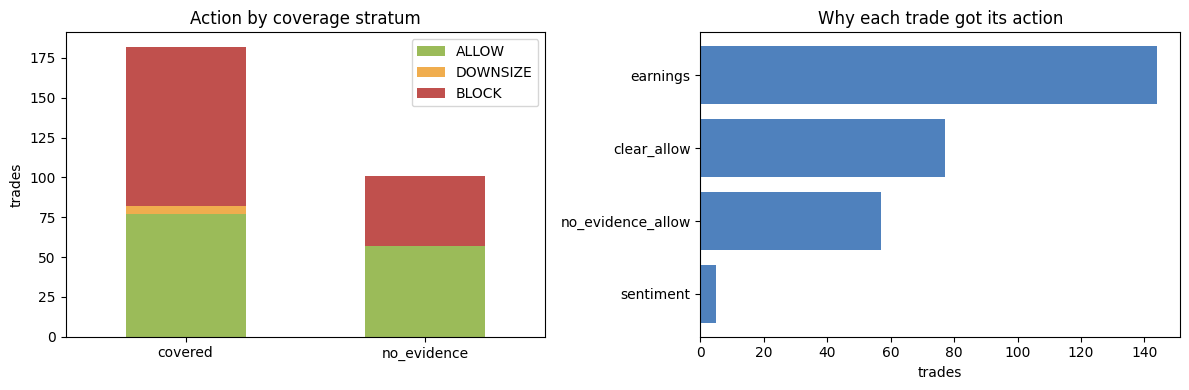

In [13]:
# ---- Chart 3: actions stratified by coverage, and the reason mix --------------------------
trade_cov = (EVID.groupby("trade_id")["evidence_status"]
                 .apply(lambda s: "covered" if (s == "COVERED").any() else "no_evidence"))
plotdf = TC.set_index("trade_id").join(trade_cov.rename("cov_stratum"))
ct = (plotdf.groupby(["cov_stratum", "action"]).size().unstack(fill_value=0)
            .reindex(columns=["ALLOW", "DOWNSIZE", "BLOCK"], fill_value=0))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ct.plot(kind="bar", stacked=True, ax=ax[0], color=["#9bbb59", "#f0ad4e", "#c0504d"])
ax[0].set_title("Action by coverage stratum"); ax[0].set_xlabel(""); ax[0].set_ylabel("trades")
ax[0].tick_params(axis="x", rotation=0); ax[0].legend(title="")
rc = TC["reason"].value_counts()
ax[1].barh(rc.index[::-1], rc.values[::-1], color="#4f81bd")
ax[1].set_title("Why each trade got its action"); ax[1].set_xlabel("trades")
plt.tight_layout(); plt.show()

### 3.2 Shock attribution — analytics only

A deterministic, offline characterization of each trade's entry stress and reversion regime, derived purely from frozen NB02 fields. It is written to its own artifact and **never** feeds the action above — it exists for interpretability, nothing more.

In [14]:
# ==============================================================================
# C.2 — Shock attribution: ANALYTICS ONLY (separate artifact, NOT a sizing input)
# ==============================================================================
# Deterministic and offline: characterizes the entry stress and reversion regime from the
# FROZEN NB2 fields. This NEVER feeds the action above; it exists for interpretability only.
hl = PAIRS_META.set_index("pair")["halflife"]
SHOCK = TRADES[["trade_id", "pair", "entry_z", "exit_z", "n_days", "trade_pnl"]].copy()
SHOCK["entry_stress"] = SHOCK["entry_z"].abs()
SHOCK["stress_band"]  = pd.cut(SHOCK["entry_stress"], [-0.01, 2, 3, np.inf],
                               labels=["sub", "stress", "extreme"])
SHOCK["halflife"]     = SHOCK["pair"].map(hl)
SHOCK["reversion"]    = np.where(SHOCK["halflife"] <= SHOCK["n_days"].clip(lower=1), "FAST", "SLOW")
SHOCK.to_csv(NB3_DIR / "shock_analytics.csv", index=False)
print("shock_analytics.csv written (analytics only — not used in sizing)")
print(SHOCK["stress_band"].value_counts().to_string())

shock_analytics.csv written (analytics only — not used in sizing)
stress_band
stress     255
extreme     28
sub          0


## 4. Layer D — Conditioned output

The only PnL transform NB03 performs: `BLOCK` drops the trade, `DOWNSIZE` halves it, `ALLOW` keeps it.
Halving is exact because spread PnL is linear in a constant-magnitude position (costs scale
identically) — no OU path is re-simulated. **`trades_conditioned.csv` is NB03's single authoritative
output.** Per NB02's own design the trade table is the primary object for this layer, while its daily
`pair_timeseries` is a separate diagnostic series that does not reconcile one-to-one with realized
trades — so NB03 deliberately does **not** emit a scaled daily P&L (that would be a second,
inconsistent source of truth). The cell below is **bookkeeping, not a verdict**: dropping or shrinking
trades changes the realized total by construction, and the dropped trades aren't a random sample, so
the change says nothing about skill. NB03 makes **no net-PnL claim**; whether the overlay helps — net
of costs, against a sensible null — is decided in NB04, built from these conditioned trades.

In [15]:
# ==============================================================================
# D.1 — trades_conditioned.csv  (mechanical accounting — NOT a performance result)
# ==============================================================================
MULT = {"ALLOW": 1.0, "DOWNSIZE": DOWNSIZE_MULT, "BLOCK": 0.0}
TC["pnl_mult"]        = TC["action"].map(MULT)
TC["pnl_conditioned"] = TC["trade_pnl"] * TC["pnl_mult"]
TC.to_csv(NB3_DIR / "trades_conditioned.csv", index=False)

base = float(TC["trade_pnl"].sum())            # frozen NB2 totals, kept for provenance only
cond = float(TC["pnl_conditioned"].sum())

# How the overlay disposes of the frozen book, with each action's pre-overlay gross PnL.
# IMPORTANT: this is bookkeeping, not a verdict. Dropping or shrinking trades changes the
# realized total *by construction* — and because blocked trades are not a random sample,
# that change says nothing about skill on its own. Whether the overlay actually helps is
# decided in NB4: portfolio-level, net of costs, stratified by coverage, against a null
# (e.g. random blocks at the same rate). NB3 makes no performance claim.
acct = TC.groupby("action")["trade_pnl"].agg(n="count", gross_pnl="sum")
print("Disposition of the frozen NB2 book (counts + pre-overlay gross PnL per action):")
print(acct.to_string())

# exact-arithmetic reconciliation — verifies the resize/drop math, not the strategy
expected = (TC.loc[TC["action"] == "ALLOW", "trade_pnl"].sum()
            + DOWNSIZE_MULT * TC.loc[TC["action"] == "DOWNSIZE", "trade_pnl"].sum())
assert abs(cond - expected) < 1e-6, "conditioned PnL does not reconcile with ALLOW + 0.5*DOWNSIZE"
print(f"\nResize/drop arithmetic reconciles "
      f"(Σ conditioned == ALLOW + {DOWNSIZE_MULT}×DOWNSIZE + 0×BLOCK). "
      f"No net-PnL claim is made here — see NB4.")

Disposition of the frozen NB2 book (counts + pre-overlay gross PnL per action):
            n   gross_pnl
action                   
ALLOW     134  282.848490
BLOCK     144   91.422822
DOWNSIZE    5   23.258779

Resize/drop arithmetic reconciles (Σ conditioned == ALLOW + 0.5×DOWNSIZE + 0×BLOCK). No net-PnL claim is made here — see NB4.


### 4.1 Provenance

A manifest pinning the inputs, parameters, action counts, and coverage so any run is reproducible from disk.

In [16]:
# ==============================================================================
# D.3 — Run manifest (provenance for offline replay)
# ==============================================================================
manifest = dict(
    timestamp_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    offline_mode=OFFLINE_MODE,
    policy=POLICY,
    params=dict(L_DAYS=L_DAYS, MIN_COVERAGE_COUNT=MIN_COVERAGE_COUNT,
                BASELINE_DAYS=BASELINE_DAYS, MIN_BASELINE_COUNT=MIN_BASELINE_COUNT,
                TONE_LOW_PCTL=TONE_LOW_PCTL, TONE_HIGH_PCTL=TONE_HIGH_PCTL,
                EARNINGS_LOOKAHEAD_DAYS=EARNINGS_LOOKAHEAD_DAYS, DOWNSIZE_MULT=DOWNSIZE_MULT),
    inputs={n: str(NB2_DIR / f) for n, f in {
        "pairs_metadata": "pairs_metadata.csv",
        "trades_table": "trades_table.csv",
        "pair_timeseries": "pair_timeseries.parquet"}.items()},
    outputs=["semantic_evidence.parquet", "trades_conditioned.csv",
             "shock_analytics.csv", "news_long.parquet", "earnings_raw.parquet"],
    counts=dict(trades=int(len(TRADES)), trade_legs=int(len(LEGS)),
                unique_tickers=int(len(UNIQUE_TICKERS))),
    action_counts={k: int(v) for k, v in TC["action"].value_counts().items()},
    coverage_pct_by_L=cov_summary,
    baseline_pnl=base, conditioned_pnl=cond,
)
(NB3_DIR / "nb3_run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(json.dumps(manifest, indent=2, default=str))

{
  "timestamp_utc": "2026-05-31T11:09:10.143817+00:00",
  "offline_mode": true,
  "policy": "earnings=BLOCK, sentiment=DOWNSIZE",
  "params": {
    "L_DAYS": 7,
    "MIN_COVERAGE_COUNT": 3,
    "BASELINE_DAYS": 180,
    "MIN_BASELINE_COUNT": 20,
    "TONE_LOW_PCTL": 10,
    "TONE_HIGH_PCTL": 90,
    "EARNINGS_LOOKAHEAD_DAYS": 33,
    "DOWNSIZE_MULT": 0.5
  },
  "inputs": {
    "pairs_metadata": "/Users/frasagui/Projects/ai-pairs-trading/artifacts/nb2_outputs/pairs_metadata.csv",
    "trades_table": "/Users/frasagui/Projects/ai-pairs-trading/artifacts/nb2_outputs/trades_table.csv",
    "pair_timeseries": "/Users/frasagui/Projects/ai-pairs-trading/artifacts/nb2_outputs/pair_timeseries.parquet"
  },
  "outputs": [
    "semantic_evidence.parquet",
    "trades_conditioned.csv",
    "shock_analytics.csv",
    "news_long.parquet",
    "earnings_raw.parquet"
  ],
  "counts": {
    "trades": 283,
    "trade_legs": 566,
    "unique_tickers": 20
  },
  "action_counts": {
    "BLOCK": 144,
    "A

## 5. Conclusion & handoff to NB04

NB03 delivers a frozen, leg-aware, strictly as-of evidence layer and a conditioned trade set, without
ever touching trade timing or OU parameters. Its headline isn't a PnL number — it's the **coverage
boundary**: the share of the book where a sentiment view can exist at all, and the honest abstention
everywhere else.

NB04 takes `trades_conditioned.csv` and the coverage strata from `semantic_evidence.parquet`,
builds its daily and portfolio series **from those conditioned trades** (and reads NB02's raw
`pair_timeseries` directly where it needs the daily MTM for regime tagging), and runs the four-variant
ablation — **Cointegration-only / OU / OU+earnings / OU+earnings+sentiment** — at the portfolio level, net of
costs, *stratified by coverage*. The expectation, given the cliff above, is that the sentiment arm
moves the needle only on the dense sub-universe. Showing precisely where the signal stops working is
the replication-boundary result.

## References

Hutto, C. J., & Gilbert, E. (2014). "VADER: A Parsimonious Rule-Based Model for
Sentiment Analysis of Social Media Text." *Proceedings of the International AAAI
Conference on Web and Social Media*, 8(1), 216–225.